In [1]:
# ==========================================
# 📘 Notebook: Análise de Métricas de Textos
# ==========================================

# ---
# 🔹 1. Importar bibliotecas
# ---
import pandas as pd
import numpy as np
from pathlib import Path
from utils import contar_caracteres, contar_palavras, legal_sentence_split

# ---
# 🔹 2. Definir funções auxiliares (já existentes no seu projeto)
# ---
# As funções abaixo são apenas placeholders.
# No seu ambiente, substitua pelos nomes reais das suas funções.

def count_sentences(text: str) -> int:
    """Conta o número de sentenças no texto."""
    return len(legal_sentence_split(text))

/home/arthur/anaconda3/envs/qwen3-env2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /home/arthur/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/arthur/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# ---
# 🔹 3. Carregar arquivos Parquet
# ---
# Ajuste os nomes/paths conforme necessário
files = [
    "/home/arthur/nlp/repo/simplification/med-simple-docs/simplifications/final_reprocess_tamarine_qwen3.6_27b_simplified_v2.parquet.final",
]

dfs = []
for file in files:
    df = pd.read_parquet(file)
    df["source_file"] = Path(file).name
    dfs.append(df)

# ---
# 🔹 4. Calcular métricas por linha
# ---
for df in dfs:
    # Original
    df["orig_chars"] = df["informacoes_ao_paciente"].apply(contar_caracteres)
    df["orig_words"] = df["informacoes_ao_paciente"].apply(contar_palavras)
    df["orig_sents"] = df["informacoes_ao_paciente"].apply(count_sentences)

    # Paraphrase
    df["para_chars"] = df["qwen3.6_27b_simplified"].apply(contar_caracteres)
    df["para_words"] = df["qwen3.6_27b_simplified"].apply(contar_palavras)
    df["para_sents"] = df["qwen3.6_27b_simplified"].apply(count_sentences)

    # Razão entre caracteres
    df["char_ratio"] = df["para_chars"] / df["orig_chars"]

# ---
# 🔹 5. Concatenar tudo em um único DataFrame global
# ---
combined_df = pd.concat(dfs, ignore_index=True)

In [7]:
import os
print(os.getcwd())
combined_df.to_parquet("statistics.parquet", index=False)

/home/arthur/nlp/repo/simplification/med-simple-docs/src


In [3]:
# ---
# 🔹 6. Estatísticas descritivas globais
# ---
cols = [
    "orig_chars", "orig_words", "orig_sents",
    "para_chars", "para_words", "para_sents",
    "char_ratio"
]

global_stats = combined_df[cols].agg(["count", "sum", "mean", "std"]).T
print("📊 Estatísticas globais (contagem, soma, média e desvio padrão):")
display(global_stats)

# ---
# 🔹 7. Estatísticas por arquivo de origem
# ---
#grouped_stats = (
#    combined_df.groupby("source_file")[cols]
#    .agg(["count", "sum", "mean", "std"])
#    .round(2)
#)
#
#print("📂 Estatísticas por arquivo:")
#display(grouped_stats)

📊 Estatísticas globais (contagem, soma, média e desvio padrão):


,count,sum,mean,std
orig_chars,7956.0,1.038259e+08,13050.013072,7104.312763
orig_words,7956.0,1.848022e+07,2322.803419,1226.570261
orig_sents,7956.0,1.002571e+06,126.014454,51.266842
para_chars,7956.0,4.267624e+07,5364.032051,1694.250405
para_words,7956.0,8.169844e+06,1026.878331,305.640681
para_sents,7956.0,7.817880e+05,98.263952,25.998293
char_ratio,7956.0,3.766768e+03,0.473450,0.144751


In [13]:
# ---
# 🔹 8. (Opcional) Salvar resultados
# ---
global_stats.to_csv("stats_global.csv")
grouped_stats.to_csv("stats_por_arquivo.csv")

print("✅ Análise concluída com sucesso!")

✅ Análise concluída com sucesso!


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from utils import contar_caracteres, contar_palavras, legal_sentence_split

# ---
# 🔹 2. Definir funções auxiliares (já existentes no seu projeto)
# ---
# As funções abaixo são apenas placeholders.
# No seu ambiente, substitua pelos nomes reais das suas funções.

def count_sentences(text: str) -> int:
    """Conta o número de sentenças no texto."""
    return len(legal_sentence_split(text))

test_df = pd.read_parquet("/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/test_random.parquet")

test_df["orig_chars"] = test_df["original_text"].apply(contar_caracteres)
test_df["orig_words"] = test_df["original_text"].apply(contar_palavras)
test_df["orig_sents"] = test_df["original_text"].apply(count_sentences)
# Paraphrase
test_df["para_chars"] = test_df["paraphrase"].apply(contar_caracteres)
test_df["para_words"] = test_df["paraphrase"].apply(contar_palavras)
test_df["para_sents"] = test_df["paraphrase"].apply(count_sentences)

print(test_df["orig_words"].mean())
print(test_df["para_words"].mean())


620.0473141942583
202.17525257577273


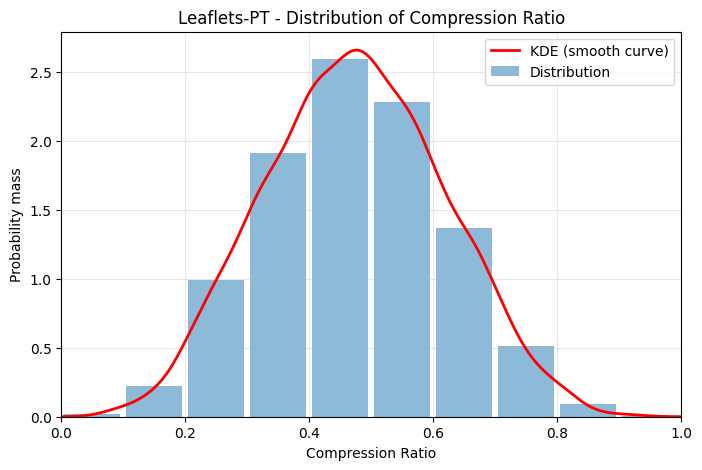

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ======================================
# 🔹 Plot da distribuição de char_ratio
# ======================================

# Remover possíveis NaN ou valores extremos
#df=pd.read_parquet('statistics.parquet')
df=combined_df.copy()
data = df["char_ratio"].dropna()
data = data[(data >= 0) & (data <= 1.0)]

# Criar bins de 0.1 em 0.1
bins = np.arange(0, 1.6, 0.1)

# Histograma normalizado (densidade)
counts, edges = np.histogram(data, bins=bins, density=True)
centers = 0.5 * (edges[1:] + edges[:-1])

# KDE (curva suave)
kde = gaussian_kde(data)
x_kde = np.linspace(0, 1.5, 300)
y_kde = kde(x_kde)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(centers, counts, width=0.09, alpha=0.5, label="Distribution")
plt.plot(x_kde, y_kde, color="red", linewidth=2, label="KDE (smooth curve)")

plt.title("Leaflets-PT - Distribution of Compression Ratio")
plt.xlabel("Compression Ratio")
plt.ylabel("Probability mass")
plt.xlim(0, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

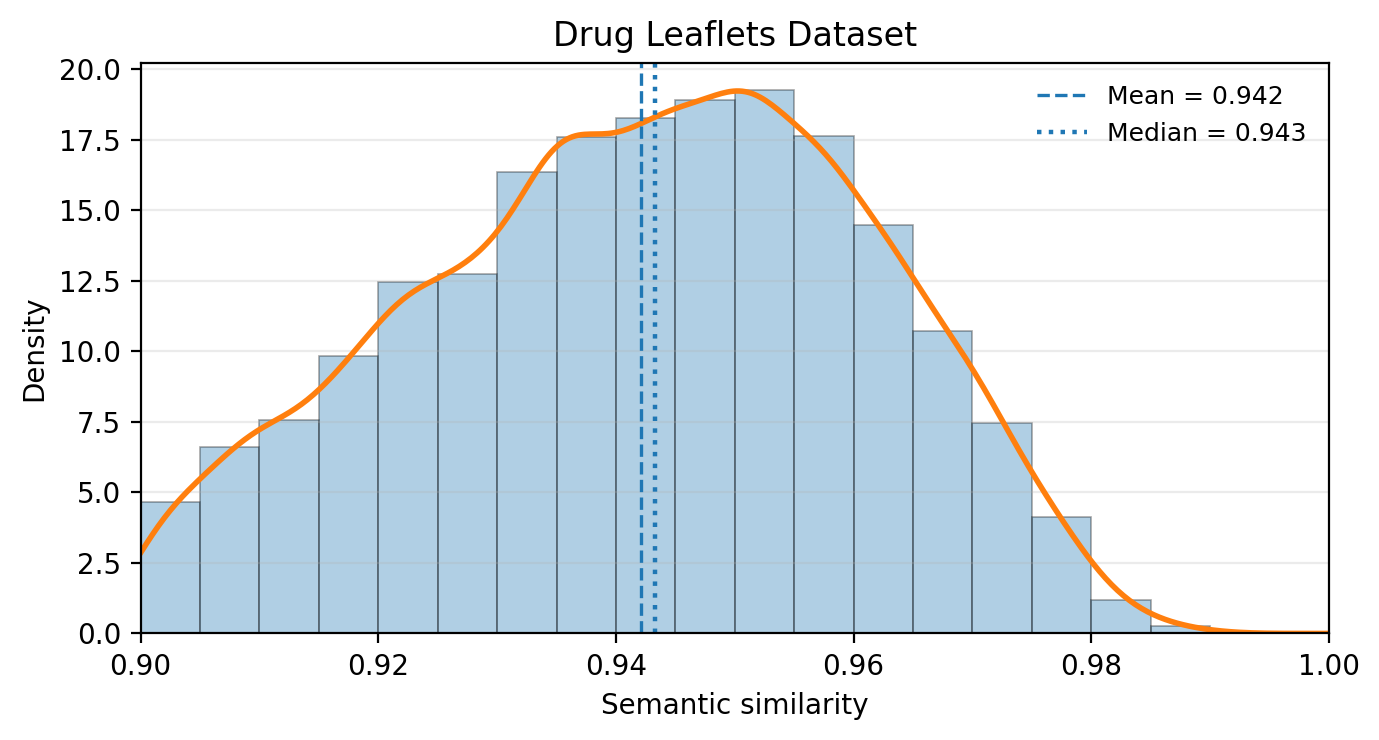

In [6]:
# Jupyter Notebook cell
# Plot the distribution of semantic similarity scores (values in [0, 1])
# Suitable for an academic NLP paper (clean histogram + KDE + summary stats).

import numpy as np
import matplotlib.pyplot as plt
similarities = df['sim'].to_list()

def plot_similarity_distribution(similarities, bins=30, title="Semantic Similarity Distribution"):
    """
    similarities: list/array of floats in [0, 1]
    bins: number of histogram bins
    """
    sims = np.asarray(similarities, dtype=float)
    sims = sims[np.isfinite(sims)]  # drop NaN/inf if any

    if sims.size == 0:
        raise ValueError("No valid similarity values to plot.")

    # Clip to [0, 1] (optional safety)
    sims = np.clip(sims, 0.0, 1.0)

    # Simple Gaussian KDE implemented with numpy (no seaborn/scipy needed)
    def gaussian_kde_1d(x, grid, bandwidth=None):
        x = np.asarray(x)
        n = x.size
        if n < 2:
            return np.zeros_like(grid)

        # Silverman's rule of thumb for bandwidth
        std = np.std(x, ddof=1)
        iqr = np.subtract(*np.percentile(x, [75, 25]))
        sigma = min(std, iqr / 1.349) if (std > 0 and iqr > 0) else std
        if bandwidth is None:
            bandwidth = 0.9 * sigma * (n ** (-1/5)) if sigma > 0 else 0.05
        bandwidth = max(bandwidth, 1e-3)

        diff = (grid[:, None] - x[None, :]) / bandwidth
        dens = np.exp(-0.5 * diff**2).sum(axis=1) / (n * bandwidth * np.sqrt(2*np.pi))
        return dens

    # Stats
    mean = float(np.mean(sims))
    median = float(np.median(sims))
    std = float(np.std(sims, ddof=1)) if sims.size > 1 else 0.0
    q25, q75 = np.percentile(sims, [25, 75])

    xmin = 0.9
    xmax = 1.0

    fig, ax = plt.subplots(figsize=(7.0, 3.8), dpi=200)

    # Histogram limitado ao intervalo desejado
    ax.hist(
        sims,
        bins=bins,
        range=(xmin, xmax),
        density=True,
        alpha=0.35,
        edgecolor="black",
        linewidth=0.6
    )

    # KDE apenas no intervalo
    grid = np.linspace(xmin, xmax, 400)
    kde = gaussian_kde_1d(sims, grid)
    ax.plot(grid, kde, linewidth=2.0)

    # Linhas de referência
    ax.axvline(mean, linestyle="--", linewidth=1.2, label=f"Mean = {mean:.3f}")
    ax.axvline(median, linestyle=":", linewidth=1.6, label=f"Median = {median:.3f}")

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Semantic similarity")
    ax.set_ylabel("Density")
    #ax.set_title("Distribution of Semantic Similarity Scores")
    ax.set_title("Drug Leaflets Dataset")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

# ----------------------------
# Example usage (replace with your list)
#similarities = [0.91, 0.87, 0.76, 0.82, 0.94, 0.68, 0.73, 0.88, 0.79, 0.91, 0.85]
plot_similarity_distribution(similarities, bins=20, title="Distribution of Semantic Similarity Scores")


In [2]:
# ---
# 🔹 3. Carregar arquivos csv
# ---
# Ajuste os nomes/paths conforme necessário
files = [
    "/home/arthurscalercio/repo/legal-doc-simplification-data/val_challenge_good.csv",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/val_challenge_hard.csv"
]

dfs = []
for file in files:
    df = pd.read_csv(file)
    df["source_file"] = Path(file).name
    dfs.append(df)

# ---
# 🔹 4. Calcular métricas por linha
# ---
for df in dfs:
    # Original
    df["orig_chars"] = df["original_text"].apply(contar_caracteres)
    df["orig_words"] = df["original_text"].apply(contar_palavras)
    df["orig_sents"] = df["original_text"].apply(count_sentences)

    # Paraphrase
    df["para_chars"] = df["paraphrase"].apply(contar_caracteres)
    df["para_words"] = df["paraphrase"].apply(contar_palavras)
    df["para_sents"] = df["paraphrase"].apply(count_sentences)

    # Razão entre caracteres
    df["char_ratio"] = df["para_chars"] / df["orig_chars"]

# ---
# 🔹 5. Concatenar tudo em um único DataFrame global
# ---
combined_df = pd.concat(dfs, ignore_index=True)

In [7]:
print(combined_df['original_text'][399])
combined_df.to_csv("challenge_sets" + ".csv", index=False)

RECURSO ESPECIAL Nº 0974180 - DF (6078/8678071-4)
DECISÃO
Trata-se de recurso especial interposto em face de acórdão assim
ementado:
“APELAÇÃO CÍVEL. DIREITO CIVIL. DIREITO PROCESSUAL CIVIL. AÇÃO DE
COBRANÇA. COERDEIRO. USUFRUTO. IMÓVEIS. ALUGUÉIS. PRESCRIÇÃO.
RECONHECIDO. RECURSO CONHECIDO E NÃO PROVIDO.
1. Segundo o princípio da actio nata, o prazo prescricional somente se inicia
quando a pretensão pode ser exercida, sendo desarrazoado que o titular de um
direito subjetivo violado tenha contra si o início do prazo prescricional quando não
há qualquer possibilidade de exercitar sua pretensão, não havendo comportamento
negligente ou desidioso de sua parte.
2. No caso em análise, discute-se o direito do autor ao recebimento de aluguéis em
razão de suposta ocupação exclusiva de imóveis do espólio do genitor. O exercício
da pretensão nasceu com o início da ocupação irregular, ou seja, com o
falecimento do de cujus, transcorridos três anos e não exercido o direito de ação,
necessário o rec

In [1]:
import pandas as pd
from pathlib import Path
from utils import contar_caracteres, contar_palavras, legal_sentence_split

def count_sentences(text: str) -> int:
    """Conta o número de sentenças no texto."""
    return len(legal_sentence_split(text))

files = [
    "/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/challenge_good_bode_results_v2.csv",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/challenge_hard_bode_results_v2.csv",
    
]

dfs = []
for file in files:
    df = pd.read_csv(file)
    df["source_file"] = Path(file).name
    dfs.append(df)

# ---
# 🔹 4. Calcular métricas por linha
# ---
for df in dfs:
    # Original
    df["orig_chars"] = df["original_text"].apply(contar_caracteres)
    df["orig_words"] = df["original_text"].apply(contar_palavras)
    df["orig_sents"] = df["original_text"].apply(count_sentences)

    # Paraphrase
    df["para_chars"] = df["bode_output"].apply(contar_caracteres)
    df["para_words"] = df["bode_output"].apply(contar_palavras)
    df["para_sents"] = df["bode_output"].apply(count_sentences)

    # Razão entre caracteres
    df["char_ratio"] = df["para_chars"] / df["orig_chars"]

# ---
# 5. Concatenar tudo em um único DataFrame global
# ---
combined_df = pd.concat(dfs, ignore_index=True)

/home/arthurscalercio/anaconda3/envs/qwen3-clone/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /home/arthurscalercio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/arthurscalercio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
print(combined_df['bode_output'][399])
combined_df.to_csv("challenge_sets_bode" + ".csv", index=False)

ese de que a prescrição tenha sido
interrompida, se o prazo prescricional iniciou-se com o trânsito em julgado da ação
de inventário ou com a manifestação do autor no processo de inventário.
3- A tese do apelante é de que o prazo prescricional iniciou-se com o trânsito em
julgado da ação de inventário.
4- A tese do relator é de que o prazo prescricional iniciou-se com a manifestação do
autor no processo de inventário.
5- A decisão do relator é de que o prazo prescricional iniciou-se com o trânsito em
julgado da ação de inventário.
6- A decisão do relator é de que o prazo prescricional iniciou-se com a manifestação do
autor no processo de inventário.
7- A decisão do relator é de que o prazo prescricional iniciou-se com o trânsito em
julgado da ação de inventário.
8- A decisão do relator é de que o prazo prescricional iniciou-se com a manifestação do
autor no processo de inventário.
9- A decisão do relator é de que o prazo prescricional iniciou-se com o trânsito em
julgado da ação de inv

In [3]:
files = [
    "/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/challenge_good_qwen2_5_results_batched.csv",
    "/home/arthurscalercio/repo/legal-doc-simplification-data/splits_output/challenge_hard_qwen2_5_results_batched_new_p2.csv",
]

dfs = []
for file in files:
    df = pd.read_csv(file)
    df["source_file"] = Path(file).name
    dfs.append(df)

# ---
# 🔹 4. Calcular métricas por linha
# ---
for df in dfs:
    # Original
    df["orig_chars"] = df["original_text"].apply(contar_caracteres)
    df["orig_words"] = df["original_text"].apply(contar_palavras)
    df["orig_sents"] = df["original_text"].apply(count_sentences)

    # Paraphrase
    df["para_chars"] = df["qwen2.5_output"].apply(contar_caracteres)
    df["para_words"] = df["qwen2.5_output"].apply(contar_palavras)
    df["para_sents"] = df["qwen2.5_output"].apply(count_sentences)

    # Razão entre caracteres
    df["char_ratio"] = df["para_chars"] / df["orig_chars"]

# ---
# 🔹 5. Concatenar tudo em um único DataFrame global
# ---
combined_df = pd.concat(dfs, ignore_index=True)

In [4]:
print(combined_df['qwen2.5_output'][399])
combined_df.to_csv("challenge_sets_qwen2.5" + ".csv", index=False)

Trata-se de recurso especial interposto contra acórdão que reconheceu a prescrição em uma ação de cobrança de aluguéis. A decisão de origem foi mantida, mas o recurso especial foi parcialmente provido para determinar que os aluguéis devem ser pagos após a efetiva oposição dos demais herdeiros, após o trânsito em julgado da ação de inventário. Os autos foram remetidos ao Tribunal de origem para regular processamento da ação de arbitramento de aluguéis.
